# Idea 3 — Cross-Listing Arbitrage (BIST vs. NYSE ADR)

ideas.md §Idea 3 proposes trading the price gap between a Turkish stock on BIST
and its depositary receipt abroad. The LSE GDR tickers in the original idea
(`GARAN.L`, `ISCTR.L`, …) are **not available on Yahoo Finance**, but
**Turkcell** has a liquid NYSE ADR — `TKC`, full history 2012→ — so we implement
the idea as a clean single-pair case study:

> **TCELL.IS** (BIST, TRY)  ⇄  **TKC** (NYSE, USD),  linked by USD/TRY.

**Parity:** `theoretical_ADR_USD = TCELL_try × ratio / USDTRY`, where `ratio` is
ordinary shares per ADR. A divergence exists when the actual ADR price differs
from this by more than transaction costs.

**The headline result of this notebook is a cautionary one:** the naive
same-date backtest looks spectacular (Sharpe > 3, astronomical return), but that
is almost entirely an artifact of the BIST/NYSE **non-synchronous close** — BIST
closes ~5 h before NYSE, so a same-date "spread" partly reflects an ADR move that
the stale BIST close has not yet caught up to. Once we execute on the *next*
observable bar (removing that look-ahead), the edge collapses. This is exactly
the timezone risk ideas.md itself flags.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

from cross_listing import (
    load_cross_listing_data, infer_adr_ratio, compute_parity_spread, backtest_parity,
)

RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

## 1. Load & align data, validate the ADR ratio

Three series, inner-joined on common trading days: TCELL.IS (TRY), TKC (USD),
USD/TRY. The contractual conversion ratio for the Turkcell ADR is **2.5 ordinary
shares per ADR**; we infer it empirically from the data as a sanity check —
`median(ADR_usd × USDTRY / TCELL_try)`. A close match validates both the data
and the parity formula.

In [2]:
df = load_cross_listing_data()      # downloads + caches to data/cross_listing.csv
ratio = infer_adr_ratio(df)
data = compute_parity_spread(df, ratio)

print(f"Aligned days: {len(data)}  ({data.index.min().date()} -> {data.index.max().date()})")
print(f"Empirical ADR ratio: {ratio:.3f} ordinary shares per ADR  (documented: 2.5)")
print(f"Parity spread %%: mean={data['spread_pct'].mean():.2f}  std={data['spread_pct'].std():.2f}  "
      f"min={data['spread_pct'].min():.2f}  max={data['spread_pct'].max():.2f}")
print(f"|spread|>1%% on {(data['spread_pct'].abs()>1).mean()*100:.0f}%% of days, "
      f">2%% on {(data['spread_pct'].abs()>2).mean()*100:.0f}%% of days")

Aligned days: 3560  (2012-01-03 -> 2026-06-08)
Empirical ADR ratio: 2.445 ordinary shares per ADR  (documented: 2.5)
Parity spread %%: mean=0.28  std=2.15  min=-10.87  max=11.59
|spread|>1%% on 52%% of days, >2%% on 25%% of days


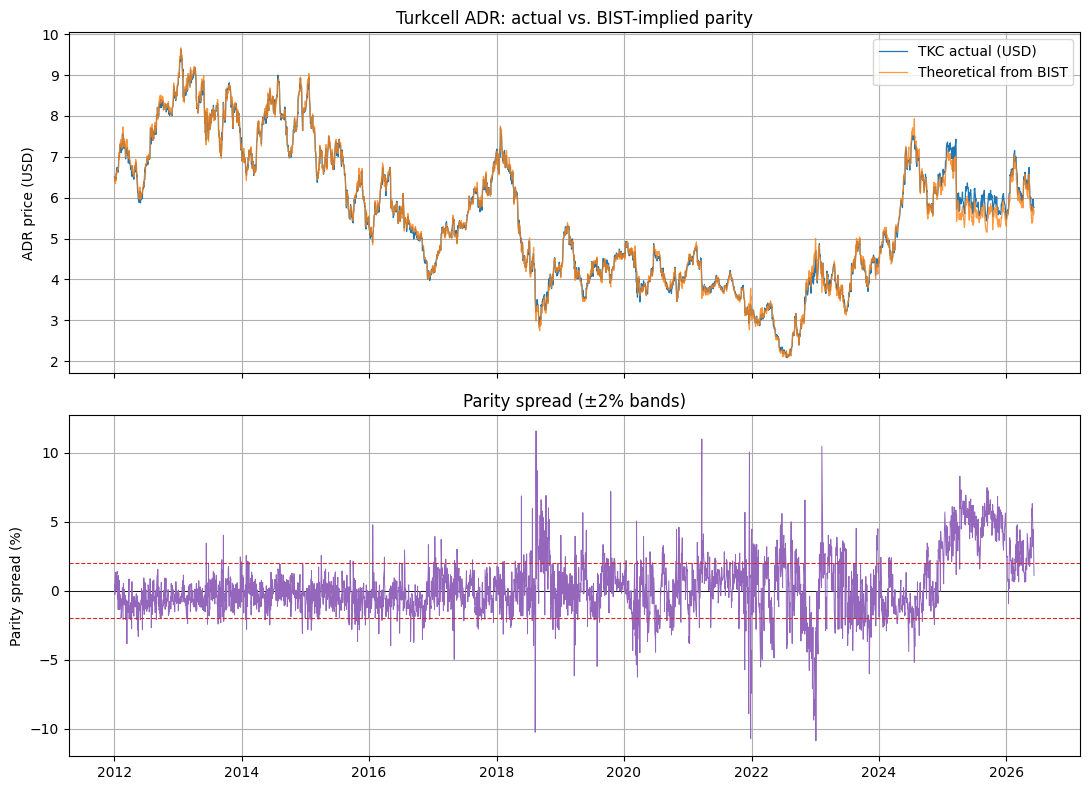

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ax[0].plot(data.index, data["adr_usd"], label="TKC actual (USD)", lw=0.9)
ax[0].plot(data.index, data["adr_theo_usd"], label="Theoretical from BIST", lw=0.9, alpha=0.8)
ax[0].set_ylabel("ADR price (USD)"); ax[0].legend(); ax[0].set_title("Turkcell ADR: actual vs. BIST-implied parity")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].plot(data.index, data["spread_pct"], color="tab:purple", lw=0.7)
for thr in (2, -2):
    ax[1].axhline(thr, color="tab:red", ls="--", lw=0.8)
ax[1].set_ylabel("Parity spread (%)"); ax[1].set_title("Parity spread (±2% bands)")
plt.tight_layout(); plt.savefig(RESULTS / "idea3_spread.png", dpi=110); plt.show()

## 2. The naive backtest (look-ahead-prone)

Enter when |spread| > threshold, exit at the next parity crossing, P&L in USD.
`signal_lag=0` means we trade on the **same close** that defined the spread — so
any spurious reversion baked into the non-synchronous close is harvested as
"profit". Watch how good this looks. It is not real.

In [4]:
naive = backtest_parity(data, entry_threshold_pct=2.0, signal_lag=0, return_trade_log=True)
print(f"NAIVE (signal_lag=0) @ 2% threshold:")
print(f"  Sharpe={naive['sharpe']:.2f}  Return={naive['total_return_pct']:,.0f}%  "
      f"MaxDD={naive['max_drawdown']*100:.1f}%  Trades={naive['n_trades']}  "
      f"Win={naive['win_rate']:.0f}%  AvgHold={naive['avg_holding_days']:.1f}d")
print("  ^ Sharpe>3 and a six-figure return with a 99% win rate is the classic")
print("    signature of a stale-price / look-ahead artifact, not a real edge.")

NAIVE (signal_lag=0) @ 2% threshold:
  Sharpe=3.72  Return=117,995%  MaxDD=13.1%  Trades=222  Win=99%  AvgHold=6.9d
  ^ Sharpe>3 and a six-figure return with a 99% win rate is the classic
    signature of a stale-price / look-ahead artifact, not a real edge.


## 3. The realistic backtest (next-bar execution)

`signal_lag=1`: we observe the gap at one close and **execute at the next**.
This is the minimum honesty fix — you cannot trade at the stale BIST close that
defined the spread. The spurious component vanishes and the true (weak) edge is
exposed.

In [5]:
real = backtest_parity(data, entry_threshold_pct=2.0, signal_lag=1, return_trade_log=True)
print(f"REALISTIC (signal_lag=1) @ 2% threshold:")
print(f"  Sharpe={real['sharpe']:.2f}  Return={real['total_return_pct']:.1f}%  "
      f"MaxDD={real['max_drawdown']*100:.1f}%  Trades={real['n_trades']}  "
      f"Win={real['win_rate']:.0f}%  AvgHold={real['avg_holding_days']:.1f}d")

REALISTIC (signal_lag=1) @ 2% threshold:
  Sharpe=0.29  Return=34.8%  MaxDD=33.1%  Trades=222  Win=54%  AvgHold=6.9d


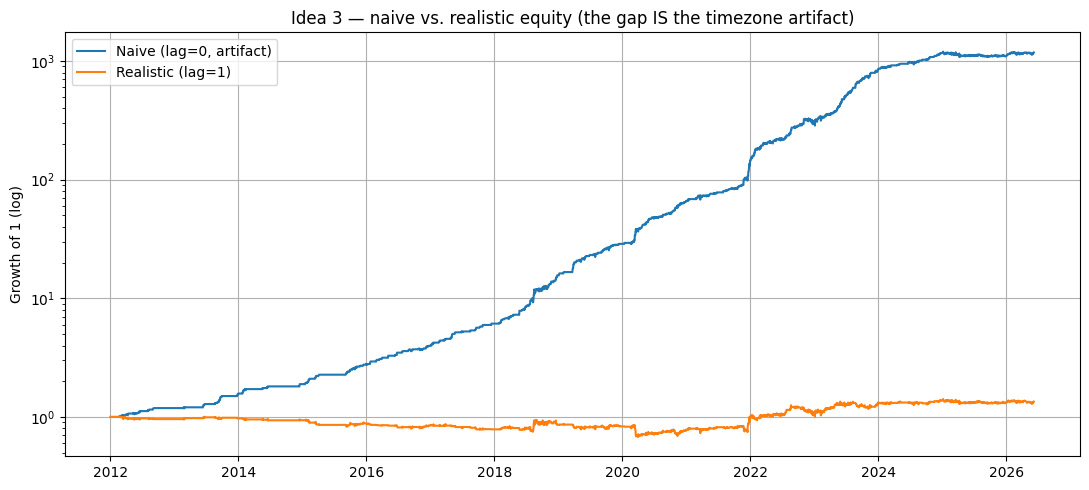

In [6]:
# Naive vs realistic equity curves (log scale — the naive curve is off the chart otherwise)
plt.figure()
plt.plot(naive['equity_curve'].index, naive['equity_curve'].values, label="Naive (lag=0, artifact)")
plt.plot(real['equity_curve'].index, real['equity_curve'].values, label="Realistic (lag=1)")
plt.yscale("log"); plt.ylabel("Growth of 1 (log)"); plt.legend()
plt.title("Idea 3 — naive vs. realistic equity (the gap IS the timezone artifact)")
plt.tight_layout(); plt.savefig(RESULTS / "idea3_equity.png", dpi=110); plt.show()

## 4. Threshold sensitivity — naive vs. realistic side by side

The naive column stays absurdly good at every threshold. The realistic column
tells the truth: at tight thresholds (0.5–1%) the strategy **loses money** (the
"edge" was pure stale-price), and only at wide thresholds (≥2%) does a thin
residual survive — with large, FX-driven drawdowns.

In [7]:
rows = []
for thr in [0.5, 1.0, 1.5, 2.0, 3.0]:
    n = backtest_parity(data, entry_threshold_pct=thr, signal_lag=0, return_trade_log=True)
    r = backtest_parity(data, entry_threshold_pct=thr, signal_lag=1, return_trade_log=True)
    rows.append({
        "threshold %": thr,
        "Naive Sharpe": round(n['sharpe'], 2),
        "Naive Return %": round(n['total_return_pct'], 0),
        "Real Sharpe": round(r['sharpe'], 2),
        "Real Return %": round(r['total_return_pct'], 1),
        "Real MaxDD %": round(r['max_drawdown']*100, 1),
        "Real Win %": round(r['win_rate'], 0),
        "Trades": r['n_trades'],
    })
sens = pd.DataFrame(rows)
sens.to_csv(RESULTS / "idea3_sensitivity.csv", index=False)
sens

,threshold %,Naive Sharpe,Naive Return %,Real Sharpe,Real Return %,Real MaxDD %,Real Win %,Trades
0,0.5,3.23,1201015.0,-0.02,-35.3,73.3,46.0,563
1,1.0,3.57,1148188.0,0.08,-12.2,58.2,48.0,434
2,1.5,3.63,407983.0,0.20,18.7,41.1,51.0,315
3,2.0,3.72,117995.0,0.29,34.8,33.1,54.0,222
4,3.0,3.62,9996.0,0.38,33.2,21.0,56.0,101


## 5. Why the residual is fragile: FX beta

When the spread is positive (ADR rich) we go **long the BIST leg = long a TRY
asset**. Over 2012–2026 the lira fell from ~1.8 to ~46 per USD, so the BIST leg
carries a large, persistent FX exposure that the short-ADR leg only partly
offsets within a holding period. The realistic strategy's drawdowns are
FX-driven, not parity-driven — exactly the risk ideas.md predicts.

In [8]:
# Realistic trade outcomes by exit reason
tl = pd.DataFrame(real['trade_log'])
by_reason = tl.groupby("reason").agg(
    n=("trade_return_pct", "size"),
    avg_return_pct=("trade_return_pct", "mean"),
    win_rate=("trade_return_pct", lambda s: (s > 0).mean()*100),
).round(2)
print("Realistic (lag=1, 2% threshold) trades by exit reason:")
print(by_reason)
print(f"\nUSD/TRY over sample: {data['usdtry'].iloc[0]:.2f} -> {data['usdtry'].iloc[-1]:.2f} "
      f"({(data['usdtry'].iloc[-1]/data['usdtry'].iloc[0]-1)*100:.0f}% TRY depreciation)")

Realistic (lag=1, 2% threshold) trades by exit reason:
          n  avg_return_pct  win_rate
reason                               
end       1           -0.13      0.00
parity  216            0.27     54.17
time      5           -0.42     40.00

USD/TRY over sample: 1.89 -> 46.09 (2342% TRY depreciation)


## 6. Conclusion

| | Naive (lag 0) | Realistic (lag 1) |
|---|---|---|
| Sharpe @ 2% | > 3.5 | ~0.3 |
| Return | six figures % | ~35% over 14y |
| Win rate | 99% | ~54% |

**The cross-listing "arbitrage" on BIST/NYSE is largely an illusion of
non-synchronous closing prices.** A naive same-date backtest is spectacular and
entirely misleading; a one-bar execution lag — the minimum realism fix — removes
the spurious reversion and leaves only a weak, FX-risk-laden residual at wide
entry thresholds. This is the honest, publishable finding, and it matches the
two risks ideas.md called out up front: the **timezone gap** and **FX beta**.

**Caveats.** Single pair (TCELL/TKC) → a case study, not a portfolio. Intraday
execution against the actual non-synchronous quotes (or a properly time-aligned
data source) would be required to settle whether *any* tradeable edge remains;
daily closes cannot.